# How Many Words Do You Need to Know to Read the Gospel of Mark? 📖

What is the fastest path to reading Mark in its original Greek text?

How many words do you actually need to learn?

Prioritizing common words is likely the fastest, most encouraging way to start reading the Greek New Testament.

In this notebook, we use Natural Language Processing (NLP) to analyze the Greek text of Mark. 

We'll find out exactly how many words make up 50%, 60%, 75%, 80%, and 90% of the entire book. 

In [21]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="thinc.shims.pytorch")

import spacy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import re
from collections import Counter

# Load the transformer model for Ancient Greek
print("Loading Greek NLP model...")
nlp = spacy.load("grc_odycy_joint_trf")

# Read the text of Mark
with open("data/NT/Greek/Mark-greek.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Remove verse numbers so they don't confuse the text analyzer
text = re.sub(r'\d+', ' ', text)

# Process the text using the NLP model (this might take a few seconds)
print("Processing text...")
doc = nlp(text)

# Extract all alphabetical words, grabbing their "lemma" (dictionary form) and part of speech
data = [
    (token.text, token.lemma_, token.pos_)
    for token in doc
    if token.is_alpha
]

df = pd.DataFrame(data, columns=["Word", "Lemma", "POS"])
print(f"Total alphabetical words found in Mark: {len(df)}")

Loading Greek NLP model...
Processing text...
Total alphabetical words found in Mark: 11223


## 1. Global Vocabulary Coverage (All Words)

First, let's look at all the words together (nouns, verbs, conjunctions like 'and', etc.).

We are grouping words by their **Lemma**. 

A lemma is the basic 'dictionary form' of a word. For example, *am*, *is*, and *are* all belong to the lemma *be*. 

By counting lemmas, we are counting the actual vocabulary terms you would study in a textbook or on flashcards.

In [22]:
# Count the frequencies of each unique lemma
lemma_counts = df["Lemma"].value_counts()
total_words = len(df)
unique_lemmas = len(lemma_counts)

print(f"Total words in Mark: {total_words}")
print(f"Unique vocabulary words (lemmas): {unique_lemmas}\n")

# Calculate how many words are needed to reach specific percentage thresholds
targets = [0.50, 0.60, 0.75, 0.80, 0.90, 1]
cumulative_sum = 0
words_needed = 0
results = []

target_idx = 0
for lemma, count in lemma_counts.items():
    cumulative_sum += count
    words_needed += 1
    
    while target_idx < len(targets) and cumulative_sum >= targets[target_idx] * total_words:
        pct = int(targets[target_idx] * 100)
        results.append((pct, words_needed))
        target_idx += 1
        
    if target_idx >= len(targets):
        break

print("--- Vocabulary Coverage ---")
for pct, needed in results:
    print(f"To understand {pct}% of the text, you need to learn {needed} unique words.")

Total words in Mark: 11223
Unique vocabulary words (lemmas): 1367

--- Vocabulary Coverage ---
To understand 50% of the text, you need to learn 25 unique words.
To understand 60% of the text, you need to learn 52 unique words.
To understand 75% of the text, you need to learn 150 unique words.
To understand 80% of the text, you need to learn 215 unique words.
To understand 90% of the text, you need to learn 481 unique words.
To understand 100% of the text, you need to learn 1367 unique words.


### Let's visualize this! 

Notice how steep the curve is at the beginning. 

This is because a few very common words (like 'and', 'the', 'he') make up a massive percentage of the text.

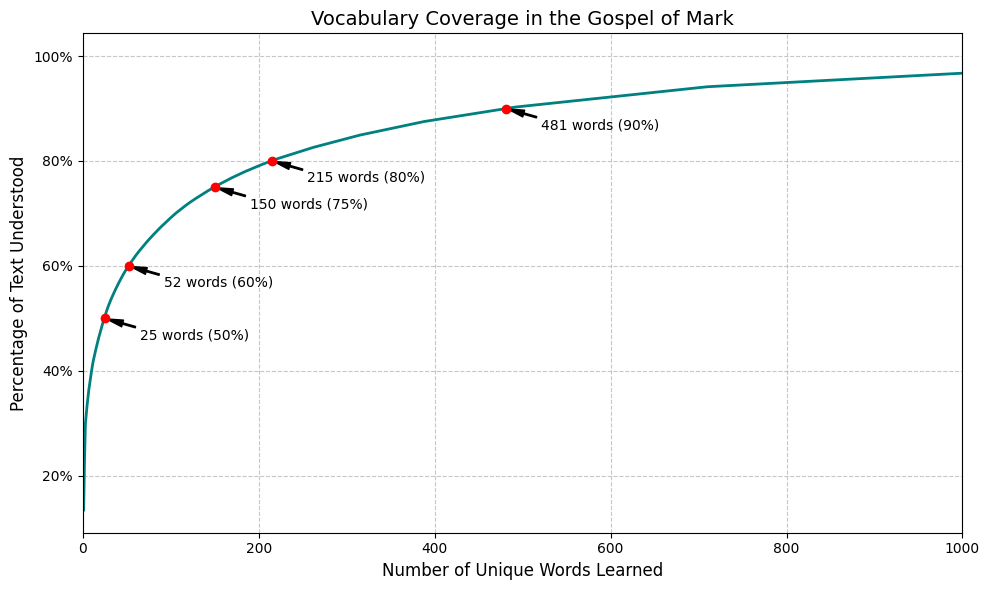

In [23]:
# Calculate cumulative percentage for plotting
cumulative_pct = (lemma_counts.cumsum() / total_words) * 100

plt.figure(figsize=(10, 6))
plt.plot(range(1, unique_lemmas + 1), cumulative_pct, color='teal', linewidth=2)

# Add markers for our thresholds
for pct, needed in results:
    plt.scatter(needed, pct, color='red', zorder=5)
    plt.annotate(f"{needed} words ({pct}%)", 
                 xy=(needed, pct), 
                 xytext=(needed + 40, pct - 4),
                 fontsize=10,
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title("Vocabulary Coverage in the Gospel of Mark", fontsize=14)
plt.xlabel("Number of Unique Words Learned", fontsize=12)
plt.ylabel("Percentage of Text Understood", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xlim(0, 1000) # zoom in slightly to focus on the curve
plt.tight_layout()
plt.show()

## 2. Verb Coverage

In Ancient Greek, verbs are often the most difficult part of speech to master.

The reason is in Greek, verbs change shape heavily based on tense, mood, and voice.

So, what if we focus *only* on verbs?

In [24]:
# Filter only the verbs
verbs_df = df[df["POS"] == "VERB"]
verb_counts = verbs_df["Lemma"].value_counts()

total_verbs = len(verbs_df)
unique_verb_lemmas = len(verb_counts)

print(f"Total verb occurrences in Mark: {total_verbs}")
print(f"Unique verb lemmas: {unique_verb_lemmas}\n")

cumulative_sum_v = 0
words_needed_v = 0
results_v = []
target_idx_v = 0

for lemma, count in verb_counts.items():
    cumulative_sum_v += count
    words_needed_v += 1
    
    while target_idx_v < len(targets) and cumulative_sum_v >= targets[target_idx_v] * total_verbs:
        pct = int(targets[target_idx_v] * 100)
        results_v.append((pct, words_needed_v))
        target_idx_v += 1
        
    if target_idx_v >= len(targets):
        break

print("--- Verb Coverage ---")
for pct, needed in results_v:
    print(f"To recognize {pct}% of the verbs, you need to learn {needed} unique verb lemmas.")

Total verb occurrences in Mark: 2451
Unique verb lemmas: 503

--- Verb Coverage ---
To recognize 50% of the verbs, you need to learn 34 unique verb lemmas.
To recognize 60% of the verbs, you need to learn 54 unique verb lemmas.
To recognize 75% of the verbs, you need to learn 112 unique verb lemmas.
To recognize 80% of the verbs, you need to learn 145 unique verb lemmas.
To recognize 90% of the verbs, you need to learn 258 unique verb lemmas.
To recognize 100% of the verbs, you need to learn 503 unique verb lemmas.


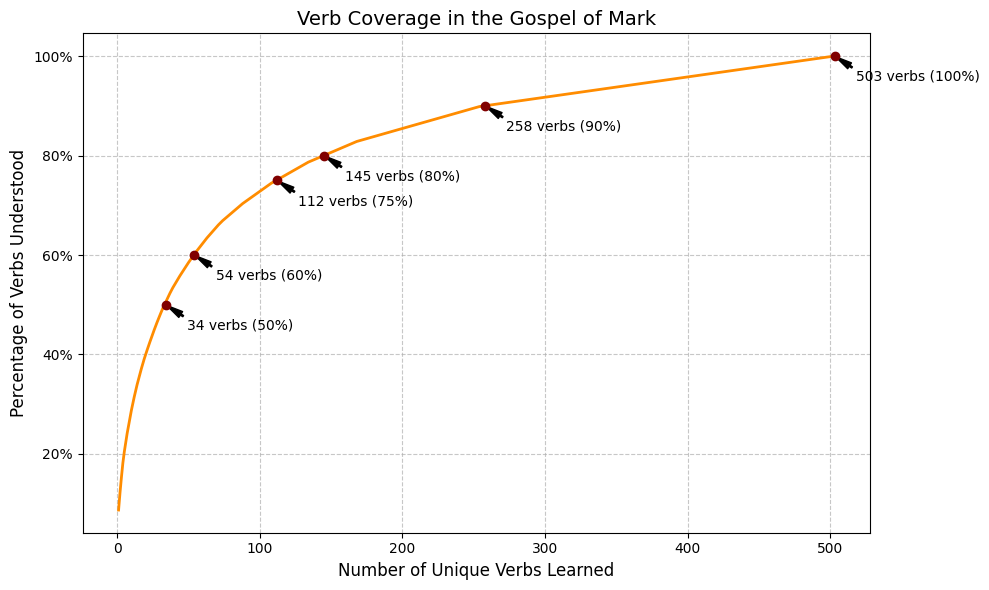

In [25]:
# Plotting the verb coverage
cumulative_pct_v = (verb_counts.cumsum() / total_verbs) * 100

plt.figure(figsize=(10, 6))
plt.plot(range(1, unique_verb_lemmas + 1), cumulative_pct_v, color='darkorange', linewidth=2)

# Add markers for our thresholds
for pct, needed in results_v:
    plt.scatter(needed, pct, color='maroon', zorder=5)
    plt.annotate(f"{needed} verbs ({pct}%)", 
                 xy=(needed, pct), 
                 xytext=(needed + 15, pct - 5),
                 fontsize=10,
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title("Verb Coverage in the Gospel of Mark", fontsize=14)
plt.xlabel("Number of Unique Verbs Learned", fontsize=12)
plt.ylabel("Percentage of Verbs Understood", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

## Conclusion

The Pareto principle (the 80/20 rule) is very real in language learning!

To comfortably read Mark:
* You only need to learn **150 words** to understand **75%** of the text.
* You need **215 words** to reach **80%** comprehension.